# Sheet 5

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch

## 2 Logistic regression: an LLM lie detector

Download the data from https://heibox.uni-heidelberg.de/f/38bd3f2a9b7944248cc2/   
Unzip it and place the lie_detection folder in the folder named `data` to get the following structure:
"data/lie_detection/datasets" and "data/lie_detection/acts".

This is how you can load a dataset of LLM activations. Use a new Datamanager if you want to have a new dataset. Use the same data manager if you want to combine datasets.

In [4]:
from lie_detection_utils import DataManager

path_to_datasets = "data/lie_detection/datasets"
path_to_acts = "data/lie_detection/acts"

# check if the datasets and activations are available
assert os.path.exists(path_to_datasets), "The path to the datasets does not exist."
assert os.path.exists(path_to_acts), "The path to the activations does not exist."

# these are the different datasets containing true and false factual statements about different topics
dataset_names = ["cities", "neg_cities", "sp_en_trans", "neg_sp_en_trans"]
dataset_name = dataset_names[0] # choose some dataset from the above datasets, index "0" loads the "cities" dataset for example

# the dataloader automatically loads the training data for us
dm = DataManager()
dm.add_dataset(dataset_name, "Llama3", "8B", "chat", layer=12, split=0.8, center=False,
                device='cpu', path_to_datasets=path_to_datasets, path_to_acts=path_to_acts)
acts_train, labels_train = dm.get('train') # train set
acts_test, labels_test = dm.get('val')
print(acts_train.shape, labels_train.shape)
print(labels_train)

torch.Size([1196, 4096]) torch.Size([1196])
tensor([0., 1., 1.,  ..., 0., 1., 0.])


In [5]:
# have a look at the statements that were fed to the LLM to produce the activations:
df = pd.read_csv(f"{path_to_datasets}/{dataset_name}.csv")
print(df.head(10))

                                        statement  label       city  \
0             The city of Krasnodar is in Russia.      1  Krasnodar   
1       The city of Krasnodar is in South Africa.      0  Krasnodar   
2                  The city of Lodz is in Poland.      1       Lodz   
3  The city of Lodz is in the Dominican Republic.      0       Lodz   
4            The city of Maracay is in Venezuela.      1    Maracay   
5                The city of Maracay is in China.      0    Maracay   
6              The city of Baku is in Azerbaijan.      1       Baku   
7                 The city of Baku is in Ukraine.      0       Baku   
8                  The city of Baoji is in China.      1      Baoji   
9              The city of Baoji is in Guatemala.      0      Baoji   

                  country correct_country  
0                  Russia          Russia  
1            South Africa          Russia  
2                  Poland          Poland  
3  the Dominican Republic          Poland 

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

def get_datsets(ds_name, split=0.8):
    
    dm = DataManager()
    dm.add_dataset(ds_name, "Llama3", "8B", "chat", layer=12, split=split, center=False,
                    device='cpu', path_to_datasets=path_to_datasets, path_to_acts=path_to_acts)
    return (dm.get('train'), dm.get('val'))


def train_logistics_classifier(X_train, Y_train, regularisation=None):
    
    model = LogisticRegression(penalty=regularisation, solver='lbfgs', max_iter=1000, tol=1e-4)
    model.fit(X_train.numpy(), Y_train.numpy())

    return model


def evaluate_logistics_classifier(X_test, Y_test, model, model_name, test_name, silent=False):
    
    predictions = model.predict(X_test.numpy())
    accuracy = accuracy_score(Y_test.numpy(), predictions)

    if not silent:
        report = classification_report(Y_test.numpy(), predictions, target_names=["False", "True"])
    
        print(f"Classification Report: '{model_name}' Model on '{test_name}' Test Dataset:")
        print(f"Test Accuracy: {accuracy:.4f}\n")
        print(report)
        print()
    
    return accuracy


(cities_acts_train, cities_label_train), (cities_acts_test, cities_label_test) = get_datsets(dataset_names[0])
(neg_cities_acts_train, neg_cities_label_train), (neg_cities_acts_test, neg_cities_label_test) = get_datsets(dataset_names[1])
(sp_en_acts_train, sp_en_label_train), (sp_en_acts_test, sp_en_label_test) = get_datsets(dataset_names[2])
(neg_sp_en_acts_train, neg_sp_en_label_train), (neg_sp_en_acts_test, neg_sp_en_label_test) = get_datsets(dataset_names[3])

cities_model = train_logistics_classifier(cities_acts_train, cities_label_train)
neg_cities_model = train_logistics_classifier(neg_cities_acts_train, neg_cities_label_train)
sp_en_model = train_logistics_classifier(sp_en_acts_train, sp_en_label_train)
neg_sp_en_model = train_logistics_classifier(neg_sp_en_acts_train, neg_sp_en_label_train)

data_labels = ["Cities", "Negative Cities", "Spanish English Translation", "Negative Spanish English Translation"]

evaluate_logistics_classifier(cities_acts_test, cities_label_test, cities_model, data_labels[0], data_labels[0])
evaluate_logistics_classifier(neg_cities_acts_test, neg_cities_label_test, neg_cities_model, data_labels[1], data_labels[1])
evaluate_logistics_classifier(sp_en_acts_test, sp_en_label_test, sp_en_model, data_labels[2], data_labels[2])
evaluate_logistics_classifier(neg_sp_en_acts_test, neg_sp_en_label_test, neg_sp_en_model, data_labels[3], data_labels[3])


# Why is this important, what does it mean?
print("Evidently, the activation vectors in all of the four datasets are linearly separable. Training accuracy approaches 100% on test dataset.")

Classification Report: 'Cities' Model on 'Cities' Test Dataset:
Test Accuracy: 1.0000

              precision    recall  f1-score   support

       False       1.00      1.00      1.00       159
        True       1.00      1.00      1.00       141

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300


Classification Report: 'Negative Cities' Model on 'Negative Cities' Test Dataset:
Test Accuracy: 1.0000

              precision    recall  f1-score   support

       False       1.00      1.00      1.00       142
        True       1.00      1.00      1.00       158

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300


Classification Report: 'Spanish English Translation' Model on 'Spanish English Translation' Test Dataset:
Test Accuracy: 1.0000

              precision

Out of distribution generalisation.

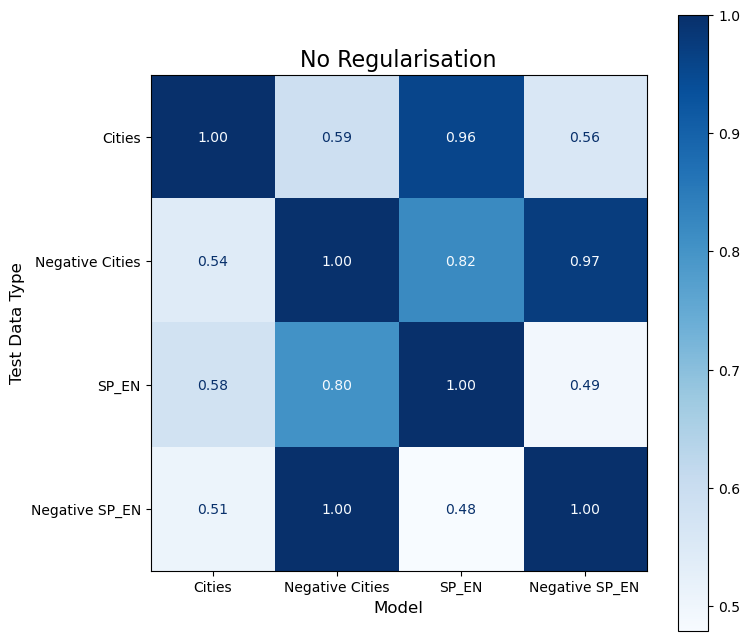

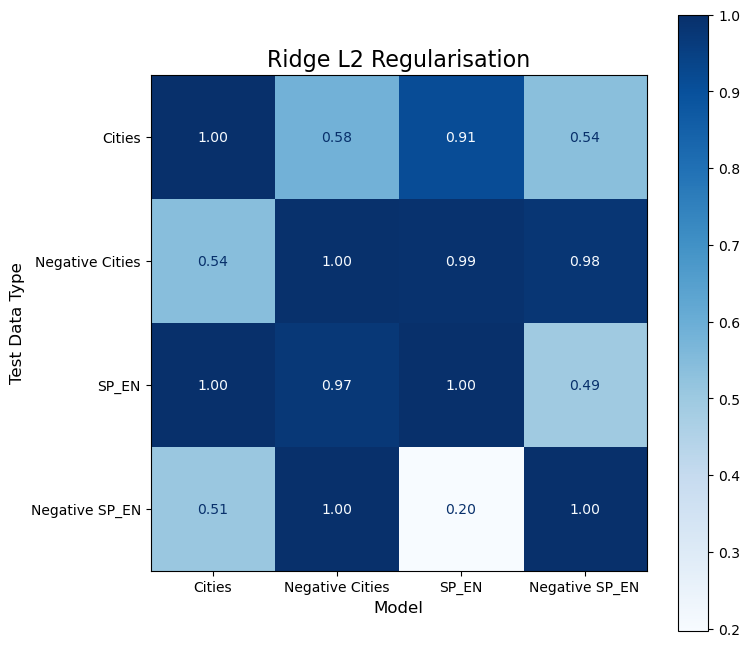

All models achieve 100% accuracy on the test data associated with them (see diagonal).
Evidently models trained on identifying normal statements, struggle to identify negated statements.
The Negative cities model performed very well on negative Spanish English Translation Data, demonstrating successful generalisation.
The same is true for the Negative Spanish English translation model, which performed very well on the Negative Cities Test Data.
While the Spanish English Translation model achieved high accuracy on the cities data, the converse is not true (assymetry).
With Ridge regularisation this assymetry is removed. Additionally, all models perform better on the other three datasets, demonstrating the benefits regularisation has on generalisation of the model.


In [87]:
from sklearn.metrics import ConfusionMatrixDisplay

train_Xs = [cities_acts_train, neg_cities_acts_train, sp_en_acts_train, neg_sp_en_acts_train]
train_Ys = [cities_label_train, neg_cities_label_train, sp_en_label_train, neg_sp_en_label_train]

test_Xs = [cities_acts_test, neg_cities_acts_test, sp_en_acts_test, neg_sp_en_acts_test]
test_Ys = [cities_label_test, neg_cities_label_test, sp_en_label_test, neg_sp_en_label_test]

models = [ cities_model, neg_cities_model, sp_en_model, neg_sp_en_model]
ridge_models = [ train_logistics_classifier(train_X, train_Y, regularisation="l2") for train_X, train_Y in zip(train_Xs, train_Ys) ]


def calculate_generalisation_accuracy_matrix(models, test_Xs, test_Ys):
    m_count = len(models)
    accuracy_matrix = np.zeros((m_count, m_count))
    
    for im, model in enumerate(models):
        for ixy, (test_X, test_Y) in enumerate(zip(test_Xs, test_Ys)):
            accuracy_matrix[im, ixy] = evaluate_logistics_classifier(test_X, test_Y, model, None, None, silent=True)

    return accuracy_matrix

def display_confusion_matrix(confusion_matrix, x_labels, y_labels, title, x_label="Model", y_label="Test Data Type"):
    
    fig, ax = plt.subplots(figsize=(8, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix.T)
    
    disp.plot(cmap="Blues", ax=ax, values_format='.2f')

    ax.set_xticks(np.arange(len(x_labels)))
    ax.set_xticklabels(x_labels, fontsize=10)
    ax.set_yticks(np.arange(len(y_labels)))
    ax.set_yticklabels(y_labels, fontsize=10)
    
    ax.set_title(title, fontsize=16)
    ax.set_xlabel(x_label, fontsize=12)
    ax.set_ylabel(y_label, fontsize=12)

    plt.show()


acc_matrix = calculate_generalisation_accuracy_matrix(models, test_Xs, test_Ys)
ridge_acc_matrix = calculate_generalisation_accuracy_matrix(ridge_models, test_Xs, test_Ys)

data_labels = ["Cities", "Negative Cities", "SP_EN", "Negative SP_EN"]

display_confusion_matrix(acc_matrix, data_labels, data_labels, "No Regularisation")
display_confusion_matrix(ridge_acc_matrix, data_labels, data_labels, "Ridge L2 Regularisation")

print("All models achieve 100% accuracy on the test data associated with them (see diagonal).")
print("Evidently models trained on identifying normal statements, struggle to identify negated statements.")
print("The Negative cities model performed very well on negative Spanish English Translation Data, demonstrating successful generalisation.")
print("The same is true for the Negative Spanish English translation model, which performed very well on the Negative Cities Test Data.")
print("While the Spanish English Translation model achieved high accuracy on the cities data, the converse is not true (assymetry).")
print("With Ridge regularisation this assymetry is removed. Additionally, all models perform better on the other three datasets, demonstrating the benefits regularisation has on generalisation of the model.")

Classification Report: 'Mixed Cities' Model on 'Mixed Cities' Test Dataset:
Test Accuracy: 0.9983

              precision    recall  f1-score   support

       False       1.00      1.00      1.00       294
        True       1.00      1.00      1.00       306

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600




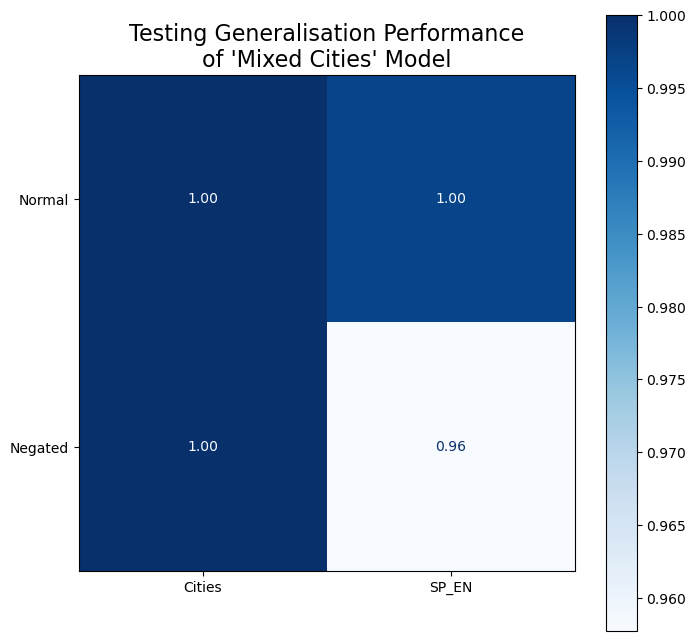

Evidently if the model is trained on both normal and negated data, it can generalise this capability from cities to Spanish English Translation.


In [113]:
pos_neg_cities_acts_train = np.concatenate((cities_acts_train, neg_cities_acts_train))
pos_neg_cities_label_train = np.concatenate((cities_label_train, neg_cities_label_train))
pos_neg_cities_acts_test = np.concatenate((cities_acts_test, neg_cities_acts_test))
pos_neg_cities_label_test = np.concatenate((cities_label_test, neg_cities_label_test))

def shuffle_data(X, Y):
    
    permutation = np.random.permutation(Y.shape[0])
    shuffled_X = X[permutation, :]
    shuffled_Y = Y[permutation]
    
    return torch.tensor(shuffled_X), torch.tensor(shuffled_Y)

np.random.seed(0)


pos_neg_cities_acts_train, pos_neg_cities_labels_train = shuffle_data(pos_neg_cities_acts_train, pos_neg_cities_label_train)
pos_neg_cities_acts_test, pos_neg_cities_labels_test = shuffle_data(pos_neg_cities_acts_test, pos_neg_cities_label_test)

pos_neg_cities_model = train_logistics_classifier(pos_neg_cities_acts_train, pos_neg_cities_labels_train)

evaluate_logistics_classifier(pos_neg_cities_acts_test, pos_neg_cities_labels_test, pos_neg_cities_model, "Mixed Cities", "Mixed Cities")

# Create matrix to visualise performance on all sub-datasets.
generalisation_matrix = np.zeros((2, 2))

generalisation_matrix[0, 0] = evaluate_logistics_classifier(cities_acts_test, cities_label_test, pos_neg_cities_model, None, None, silent=True)
generalisation_matrix[1, 0] = evaluate_logistics_classifier(neg_cities_acts_test, neg_cities_label_test, pos_neg_cities_model, None, None, silent=True)
generalisation_matrix[0, 1] = evaluate_logistics_classifier(sp_en_acts_test, sp_en_label_test, pos_neg_cities_model, None, None, silent=True)
generalisation_matrix[1, 1] = evaluate_logistics_classifier(neg_sp_en_acts_test, neg_sp_en_label_test, pos_neg_cities_model, None, None, silent=True)

x_labels = ["Cities", "SP_EN"]
y_labels = ["Normal", "Negated"]

display_confusion_matrix(generalisation_matrix, x_labels, y_labels, "Testing Generalisation Performance\nof 'Mixed Cities' Model", x_label="", y_label="")

print("Evidently if the model is trained on both normal and negated data, it can generalise this capability from cities to Spanish English Translation.")

## 3 Log-sum-exp and soft(arg)max
### (b)

### (c)

## 4 Linear regions of MLPs